In [1]:
# Customer Churn Prediction and Retention Risk Analysis
# Project setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

project_root = Path.cwd().parent
raw_path = project_root / "data" / "raw"
cleaned_path = project_root / "data" / "cleaned"
image_path = project_root / "images"

raw_path.mkdir(parents=True, exist_ok=True)
cleaned_path.mkdir(parents=True, exist_ok=True)
image_path.mkdir(parents=True, exist_ok=True)

print("Project folders ready")
print("Raw data folder:", raw_path)
print("Cleaned data folder:", cleaned_path)
print("Images folder:", image_path)

Project folders ready
Raw data folder: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/raw
Cleaned data folder: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned
Images folder: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images


In [2]:
# Create a 10,000 row customer churn dataset

num_customers = 10000

customer_data = pd.DataFrame({
    "customer_id": np.arange(1, num_customers + 1),
    "customer_segment": np.random.choice(
        ["Small Business", "Mid Market", "Enterprise", "Consumer"],
        num_customers,
        p=[0.35, 0.30, 0.20, 0.15]
    ),
    "contract_type": np.random.choice(
        ["Month to Month", "Annual", "Two Year"],
        num_customers,
        p=[0.50, 0.35, 0.15]
    ),
    "region": np.random.choice(
        ["South", "West", "Midwest", "Northeast"],
        num_customers,
        p=[0.32, 0.27, 0.21, 0.20]
    ),
    "tenure_months": np.random.randint(1, 73, num_customers),
    "monthly_revenue": np.random.normal(loc=185, scale=65, size=num_customers).round(2),
    "support_tickets_last_90_days": np.random.poisson(lam=2.2, size=num_customers),
    "late_payments_last_12_months": np.random.poisson(lam=1.1, size=num_customers),
    "product_usage_score": np.random.normal(loc=68, scale=18, size=num_customers).round(2),
    "satisfaction_score": np.random.normal(loc=7.2, scale=1.8, size=num_customers).round(1),
    "last_login_days_ago": np.random.randint(0, 121, num_customers),
    "discount_percent": np.random.choice(
        [0, 5, 10, 15, 20, 25],
        num_customers,
        p=[0.40, 0.20, 0.17, 0.12, 0.08, 0.03]
    )
})

customer_data["monthly_revenue"] = customer_data["monthly_revenue"].clip(lower=25)
customer_data["product_usage_score"] = customer_data["product_usage_score"].clip(lower=0, upper=100)
customer_data["satisfaction_score"] = customer_data["satisfaction_score"].clip(lower=1, upper=10)

# Build realistic churn probability
churn_probability = (
    0.08
    + np.where(customer_data["contract_type"] == "Month to Month", 0.18, 0)
    + np.where(customer_data["tenure_months"] < 12, 0.12, 0)
    + np.where(customer_data["support_tickets_last_90_days"] >= 4, 0.10, 0)
    + np.where(customer_data["late_payments_last_12_months"] >= 3, 0.08, 0)
    + np.where(customer_data["product_usage_score"] < 45, 0.16, 0)
    + np.where(customer_data["satisfaction_score"] < 6, 0.15, 0)
    + np.where(customer_data["last_login_days_ago"] > 45, 0.12, 0)
    - np.where(customer_data["contract_type"] == "Two Year", 0.08, 0)
    - np.where(customer_data["tenure_months"] > 36, 0.06, 0)
)

churn_probability = np.clip(churn_probability, 0.02, 0.85)

customer_data["churn_probability"] = churn_probability.round(4)
customer_data["churned"] = np.random.binomial(1, churn_probability)

customer_data["annual_revenue"] = (customer_data["monthly_revenue"] * 12).round(2)

raw_file = raw_path / "customer_churn_10000_rows.csv"
customer_data.to_csv(raw_file, index=False)

print("Raw customer churn dataset created")
print("Rows:", len(customer_data))
print("File:", raw_file)
print("Churn rate:", round(customer_data["churned"].mean() * 100, 2), "%")

customer_data.head()

Raw customer churn dataset created
Rows: 10000
File: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/raw/customer_churn_10000_rows.csv
Churn rate: 30.26 %


,customer_id,customer_segment,contract_type,region,tenure_months,monthly_revenue,support_tickets_last_90_days,late_payments_last_12_months,product_usage_score,satisfaction_score,last_login_days_ago,discount_percent,churn_probability,churned,annual_revenue
0,1,Mid Market,Month to Month,Midwest,38,304.82,2,0,84.09,8.9,88,0,0.32,0,3657.84
1,2,Consumer,Month to Month,South,33,66.23,4,1,49.22,8.6,26,20,0.36,1,794.76
2,3,Enterprise,Month to Month,West,6,172.19,0,1,55.08,6.0,9,10,0.38,0,2066.28
3,4,Mid Market,Annual,Midwest,13,213.79,1,1,89.20,6.8,118,10,0.20,0,2565.48
4,5,Small Business,Month to Month,West,20,208.74,1,0,69.88,4.8,58,0,0.53,1,2504.88


In [3]:
# Load dataset and create customer churn summary tables

df = pd.read_csv(raw_file)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Overall churn rate:", round(df["churned"].mean() * 100, 2), "%")

df.head()

Rows: 10000
Columns: 15
Overall churn rate: 30.26 %


,customer_id,customer_segment,contract_type,region,tenure_months,monthly_revenue,support_tickets_last_90_days,late_payments_last_12_months,product_usage_score,satisfaction_score,last_login_days_ago,discount_percent,churn_probability,churned,annual_revenue
0,1,Mid Market,Month to Month,Midwest,38,304.82,2,0,84.09,8.9,88,0,0.32,0,3657.84
1,2,Consumer,Month to Month,South,33,66.23,4,1,49.22,8.6,26,20,0.36,1,794.76
2,3,Enterprise,Month to Month,West,6,172.19,0,1,55.08,6.0,9,10,0.38,0,2066.28
3,4,Mid Market,Annual,Midwest,13,213.79,1,1,89.20,6.8,118,10,0.20,0,2565.48
4,5,Small Business,Month to Month,West,20,208.74,1,0,69.88,4.8,58,0,0.53,1,2504.88


In [4]:
# Churn summary by customer segment

segment_churn_summary = (
    df
    .groupby("customer_segment", as_index=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_monthly_revenue=("monthly_revenue", "mean"),
        average_product_usage_score=("product_usage_score", "mean"),
        average_satisfaction_score=("satisfaction_score", "mean")
    )
)

segment_churn_summary["churn_rate"] = (
    segment_churn_summary["churned_customers"] 
    / segment_churn_summary["total_customers"]
).round(4)

segment_churn_summary = segment_churn_summary.sort_values("churn_rate", ascending=False)

segment_churn_summary

,customer_segment,total_customers,churned_customers,average_monthly_revenue,average_product_usage_score,average_satisfaction_score,churn_rate
2,Mid Market,3048,946,183.818802,67.378478,7.142093,0.3104
3,Small Business,3555,1073,186.253432,67.663049,7.144135,0.3018
1,Enterprise,1949,583,185.078132,67.540452,7.192201,0.2991
0,Consumer,1448,424,187.433301,68.394441,7.063467,0.2928


In [5]:
# Churn summary by contract type

contract_churn_summary = (
    df
    .groupby("contract_type", as_index=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_monthly_revenue=("monthly_revenue", "mean"),
        average_tenure_months=("tenure_months", "mean"),
        average_satisfaction_score=("satisfaction_score", "mean")
    )
)

contract_churn_summary["churn_rate"] = (
    contract_churn_summary["churned_customers"] 
    / contract_churn_summary["total_customers"]
).round(4)

contract_churn_summary = contract_churn_summary.sort_values("churn_rate", ascending=False)

contract_churn_summary

,contract_type,total_customers,churned_customers,average_monthly_revenue,average_tenure_months,average_satisfaction_score,churn_rate
1,Month to Month,4936,1988,184.618882,36.200365,7.143578,0.4028
0,Annual,3498,779,186.204648,36.815323,7.132905,0.2227
2,Two Year,1566,259,186.404023,35.543423,7.152235,0.1654


In [6]:
# Advanced churn risk feature engineering

df["customer_lifetime_value"] = (
    df["monthly_revenue"] * df["tenure_months"]
).round(2)

df["estimated_annual_revenue_at_risk"] = np.where(
    df["churned"] == 1,
    df["annual_revenue"],
    0
).round(2)

df["usage_risk_flag"] = np.where(df["product_usage_score"] < 45, 1, 0)
df["satisfaction_risk_flag"] = np.where(df["satisfaction_score"] < 6, 1, 0)
df["login_risk_flag"] = np.where(df["last_login_days_ago"] > 45, 1, 0)
df["support_risk_flag"] = np.where(df["support_tickets_last_90_days"] >= 4, 1, 0)
df["payment_risk_flag"] = np.where(df["late_payments_last_12_months"] >= 3, 1, 0)

df["total_risk_flags"] = (
    df["usage_risk_flag"]
    + df["satisfaction_risk_flag"]
    + df["login_risk_flag"]
    + df["support_risk_flag"]
    + df["payment_risk_flag"]
)

df["risk_band"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.20, 0.40, 0.60, 1.00],
    labels=["Low Risk", "Moderate Risk", "High Risk", "Critical Risk"],
    include_lowest=True
)

df["retention_priority"] = np.select(
    [
        (df["risk_band"] == "Critical Risk") & (df["annual_revenue"] >= 2500),
        (df["risk_band"] == "High Risk") & (df["annual_revenue"] >= 2500),
        (df["risk_band"].isin(["High Risk", "Critical Risk"])),
        (df["risk_band"] == "Moderate Risk")
    ],
    [
        "Immediate Executive Outreach",
        "High Priority Retention Campaign",
        "Standard Retention Campaign",
        "Monitor and Nurture"
    ],
    default="Low Priority"
)

print("Advanced churn risk features created")
df[
    [
        "customer_id",
        "customer_segment",
        "contract_type",
        "monthly_revenue",
        "annual_revenue",
        "customer_lifetime_value",
        "churn_probability",
        "churned",
        "risk_band",
        "total_risk_flags",
        "retention_priority"
    ]
].head()

Advanced churn risk features created


,customer_id,customer_segment,contract_type,monthly_revenue,annual_revenue,customer_lifetime_value,churn_probability,churned,risk_band,total_risk_flags,retention_priority
0,1,Mid Market,Month to Month,304.82,3657.84,11583.16,0.32,0,Moderate Risk,1,Monitor and Nurture
1,2,Consumer,Month to Month,66.23,794.76,2185.59,0.36,1,Moderate Risk,1,Monitor and Nurture
2,3,Enterprise,Month to Month,172.19,2066.28,1033.14,0.38,0,Moderate Risk,0,Monitor and Nurture
3,4,Mid Market,Annual,213.79,2565.48,2779.27,0.20,0,Low Risk,1,Low Priority
4,5,Small Business,Month to Month,208.74,2504.88,4174.80,0.53,1,High Risk,2,High Priority Retention Campaign


In [7]:
# Revenue at risk and retention priority summary

risk_band_summary = (
    df
    .groupby("risk_band", observed=True, as_index=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_churn_probability=("churn_probability", "mean"),
        total_annual_revenue=("annual_revenue", "sum"),
        estimated_revenue_at_risk=("estimated_annual_revenue_at_risk", "sum"),
        average_lifetime_value=("customer_lifetime_value", "mean"),
        average_risk_flags=("total_risk_flags", "mean")
    )
)

risk_band_summary["churn_rate"] = (
    risk_band_summary["churned_customers"] / risk_band_summary["total_customers"]
).round(4)

risk_band_summary = risk_band_summary.sort_values("average_churn_probability", ascending=False)

retention_priority_summary = (
    df
    .groupby("retention_priority", as_index=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_churn_probability=("churn_probability", "mean"),
        total_annual_revenue=("annual_revenue", "sum"),
        estimated_revenue_at_risk=("estimated_annual_revenue_at_risk", "sum")
    )
)

retention_priority_summary["churn_rate"] = (
    retention_priority_summary["churned_customers"]
    / retention_priority_summary["total_customers"]
).round(4)

retention_priority_summary = retention_priority_summary.sort_values(
    "estimated_revenue_at_risk",
    ascending=False
)

risk_band_summary

,risk_band,total_customers,churned_customers,average_churn_probability,total_annual_revenue,estimated_revenue_at_risk,average_lifetime_value,average_risk_flags,churn_rate
3,Critical Risk,387,259,0.670052,843670.32,551798.16,3013.515375,2.767442,0.6693
2,High Risk,2146,1040,0.487176,4715851.92,2284074.72,5431.324963,1.918453,0.4846
1,Moderate Risk,4043,1265,0.316733,9118834.92,2890581.96,6761.426663,1.294831,0.3129
0,Low Risk,3424,462,0.126215,7576019.16,1025062.20,8011.351043,0.626752,0.1349


In [8]:
retention_priority_summary

,retention_priority,total_customers,churned_customers,average_churn_probability,total_annual_revenue,estimated_revenue_at_risk,churn_rate
3,Monitor and Nurture,4043,1265,0.316733,9118834.92,2890581.96,0.3129
4,Standard Retention Campaign,1639,846,0.515296,2858006.40,1474967.40,0.5162
0,High Priority Retention Campaign,749,363,0.485421,2263700.76,1089934.68,0.4846
2,Low Priority,3424,462,0.126215,7576019.16,1025062.20,0.1349
1,Immediate Executive Outreach,145,90,0.666483,437815.08,270970.80,0.6207


In [9]:
# Machine learning churn prediction model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

feature_columns = [
    "customer_segment",
    "contract_type",
    "region",
    "tenure_months",
    "monthly_revenue",
    "support_tickets_last_90_days",
    "late_payments_last_12_months",
    "product_usage_score",
    "satisfaction_score",
    "last_login_days_ago",
    "discount_percent",
    "annual_revenue",
    "customer_lifetime_value",
    "total_risk_flags"
]

target_column = "churned"

X = df[feature_columns]
y = df[target_column]

categorical_features = ["customer_segment", "contract_type", "region"]
numeric_features = [
    "tenure_months",
    "monthly_revenue",
    "support_tickets_last_90_days",
    "late_payments_last_12_months",
    "product_usage_score",
    "satisfaction_score",
    "last_login_days_ago",
    "discount_percent",
    "annual_revenue",
    "customer_lifetime_value",
    "total_risk_flags"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42
    ),
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred_probability = pipeline.predict_proba(X_test)[:, 1]

    trained_models[model_name] = pipeline

    model_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_probability)
    })

model_performance = pd.DataFrame(model_results).round(4)

model_performance

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.7156,0.5710,0.2394,0.3374,0.7015
1,Random Forest Classifier,0.7104,0.5702,0.1720,0.2642,0.7056
2,Gradient Boosting Classifier,0.7172,0.5759,0.2460,0.3448,0.7049


In [10]:
# Select best model based on ROC AUC

best_model_name = model_performance.sort_values("roc_auc", ascending=False).iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

best_model_predictions = best_model.predict(X_test)
best_model_probabilities = best_model.predict_proba(X_test)[:, 1]

confusion = confusion_matrix(y_test, best_model_predictions)

confusion_matrix_df = pd.DataFrame(
    confusion,
    index=["Actual Not Churned", "Actual Churned"],
    columns=["Predicted Not Churned", "Predicted Churned"]
)

confusion_matrix_df

Best model: Random Forest Classifier


,Predicted Not Churned,Predicted Churned
Actual Not Churned,1646,98
Actual Churned,626,130


In [11]:
# Feature importance from the best tree based model

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": model_step.feature_importances_
    }).sort_values("importance", ascending=False)

    feature_importance["importance"] = feature_importance["importance"].round(4)

else:
    coefficients = model_step.coef_[0]
    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(coefficients)
    }).sort_values("importance", ascending=False)

    feature_importance["importance"] = feature_importance["importance"].round(4)

feature_importance.head(15)

,feature,importance
5,categorical__contract_type_Month to Month,0.1215
21,numeric__total_risk_flags,0.1128
11,numeric__tenure_months,0.0989
20,numeric__customer_lifetime_value,0.0943
17,numeric__last_login_days_ago,0.0924
16,numeric__satisfaction_score,0.0893
15,numeric__product_usage_score,0.0822
12,numeric__monthly_revenue,0.0605
19,numeric__annual_revenue,0.0587
6,categorical__contract_type_Two Year,0.0330


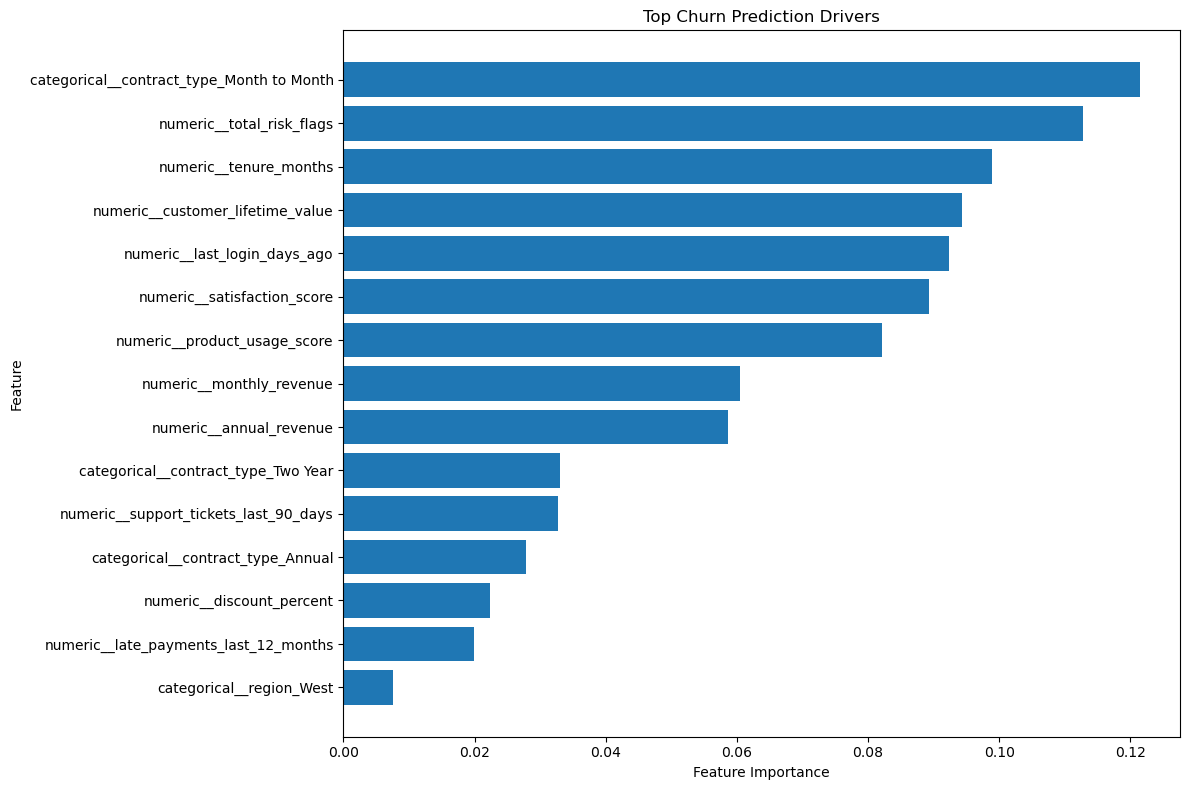

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images/top_churn_prediction_drivers.png


In [12]:
# Visualize top churn prediction drivers

top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(12, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Churn Prediction Drivers")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_importance_path = image_path / "top_churn_prediction_drivers.png"
plt.savefig(feature_importance_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", feature_importance_path)

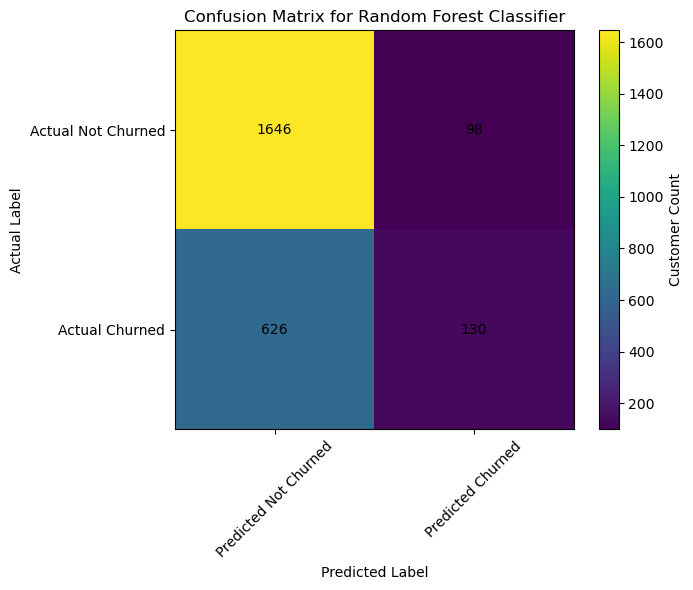

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images/churn_model_confusion_matrix.png


In [13]:
# Visualize confusion matrix

plt.figure(figsize=(7, 6))
plt.imshow(confusion_matrix_df, aspect="auto")
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    ticks=np.arange(len(confusion_matrix_df.columns)),
    labels=confusion_matrix_df.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(confusion_matrix_df.index)),
    labels=confusion_matrix_df.index
)

for i in range(confusion_matrix_df.shape[0]):
    for j in range(confusion_matrix_df.shape[1]):
        plt.text(
            j,
            i,
            confusion_matrix_df.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Customer Count")
plt.tight_layout()

confusion_matrix_path = image_path / "churn_model_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", confusion_matrix_path)

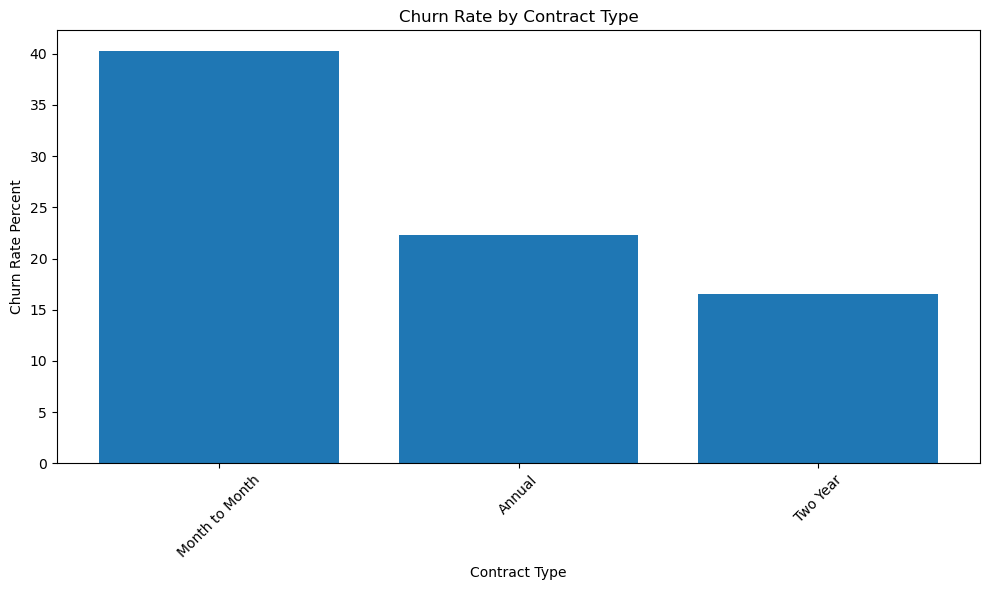

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images/churn_rate_by_contract_type.png


In [14]:
# Churn rate by contract type visual

plt.figure(figsize=(10, 6))
plt.bar(contract_churn_summary["contract_type"], contract_churn_summary["churn_rate"] * 100)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate Percent")
plt.xticks(rotation=45)
plt.tight_layout()

contract_churn_path = image_path / "churn_rate_by_contract_type.png"
plt.savefig(contract_churn_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", contract_churn_path)

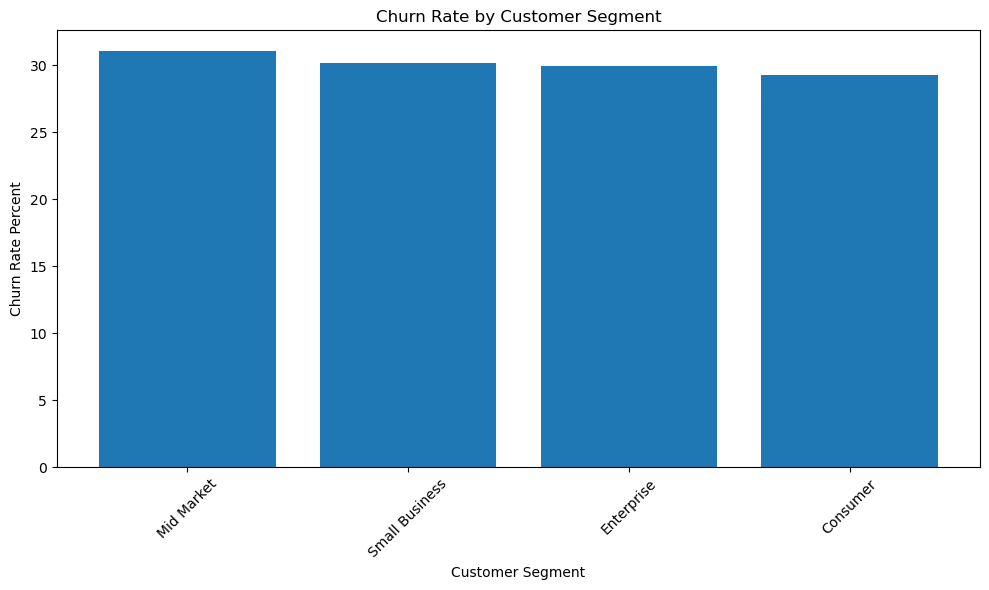

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images/churn_rate_by_customer_segment.png


In [15]:
# Churn rate by customer segment visual

plt.figure(figsize=(10, 6))
plt.bar(segment_churn_summary["customer_segment"], segment_churn_summary["churn_rate"] * 100)
plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate Percent")
plt.xticks(rotation=45)
plt.tight_layout()

segment_churn_path = image_path / "churn_rate_by_customer_segment.png"
plt.savefig(segment_churn_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", segment_churn_path)

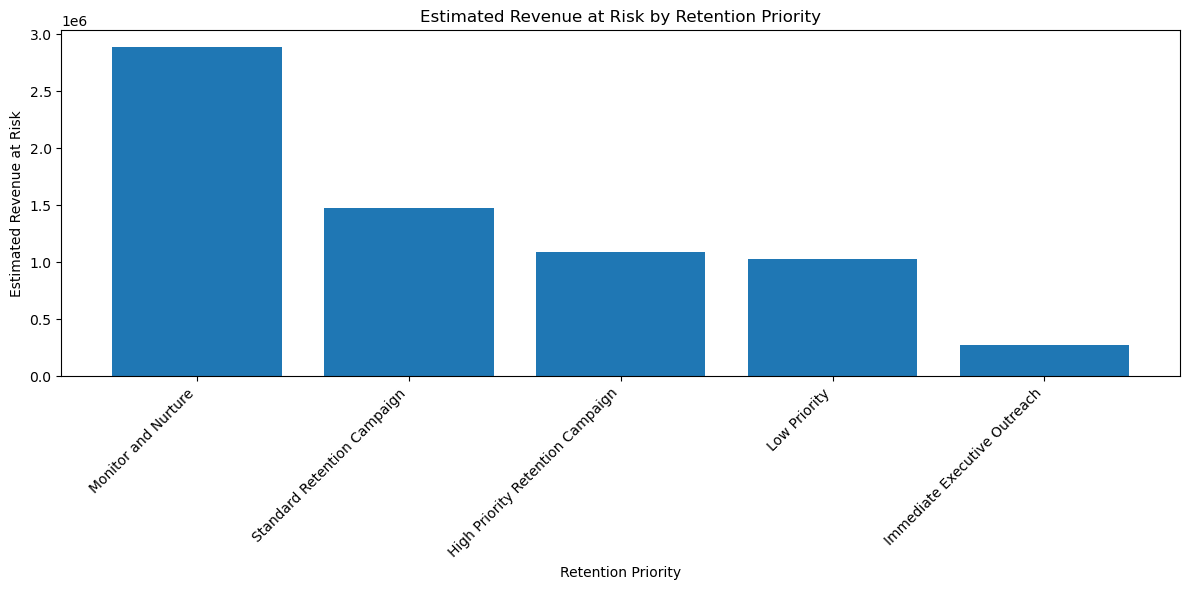

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images/revenue_at_risk_by_retention_priority.png


In [16]:
# Revenue at risk by retention priority visual

plt.figure(figsize=(12, 6))
plt.bar(
    retention_priority_summary["retention_priority"],
    retention_priority_summary["estimated_revenue_at_risk"]
)
plt.title("Estimated Revenue at Risk by Retention Priority")
plt.xlabel("Retention Priority")
plt.ylabel("Estimated Revenue at Risk")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

revenue_at_risk_path = image_path / "revenue_at_risk_by_retention_priority.png"
plt.savefig(revenue_at_risk_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", revenue_at_risk_path)

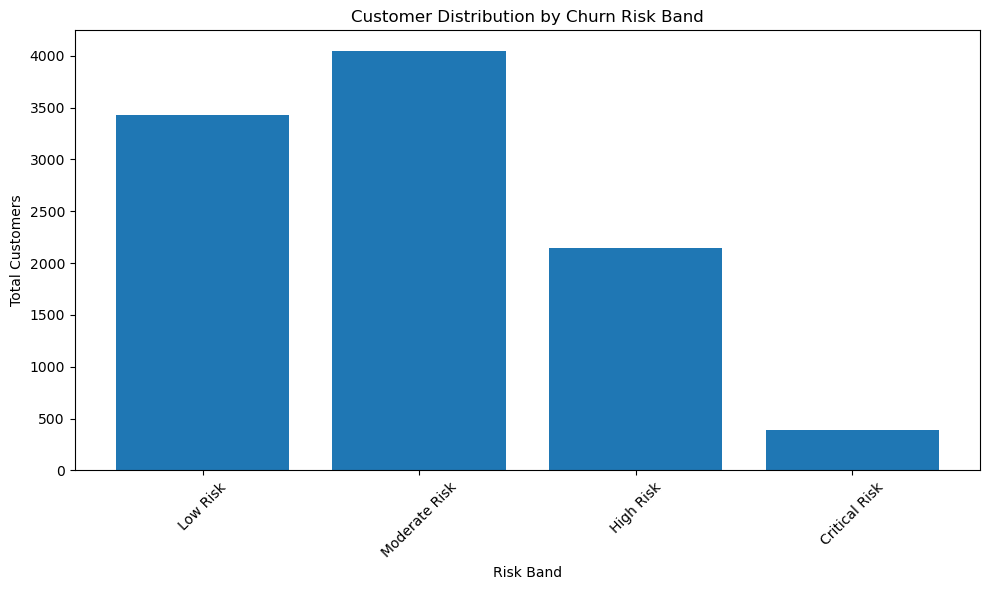

Saved: /Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/images/customer_distribution_by_risk_band.png


In [17]:
# Churn risk distribution visual

risk_distribution = (
    df
    .groupby("risk_band", observed=True, as_index=False)
    .agg(total_customers=("customer_id", "count"))
)

plt.figure(figsize=(10, 6))
plt.bar(risk_distribution["risk_band"].astype(str), risk_distribution["total_customers"])
plt.title("Customer Distribution by Churn Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Total Customers")
plt.xticks(rotation=45)
plt.tight_layout()

risk_distribution_path = image_path / "customer_distribution_by_risk_band.png"
plt.savefig(risk_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", risk_distribution_path)

In [18]:
# Save cleaned datasets and model outputs

cleaned_customer_file = cleaned_path / "customer_churn_scored_dataset.csv"
segment_summary_file = cleaned_path / "segment_churn_summary.csv"
contract_summary_file = cleaned_path / "contract_churn_summary.csv"
risk_band_summary_file = cleaned_path / "risk_band_summary.csv"
retention_priority_summary_file = cleaned_path / "retention_priority_summary.csv"
model_performance_file = cleaned_path / "model_performance_summary.csv"
confusion_matrix_file = cleaned_path / "confusion_matrix.csv"
feature_importance_file = cleaned_path / "feature_importance.csv"

df.to_csv(cleaned_customer_file, index=False)
segment_churn_summary.to_csv(segment_summary_file, index=False)
contract_churn_summary.to_csv(contract_summary_file, index=False)
risk_band_summary.to_csv(risk_band_summary_file, index=False)
retention_priority_summary.to_csv(retention_priority_summary_file, index=False)
model_performance.to_csv(model_performance_file, index=False)
confusion_matrix_df.to_csv(confusion_matrix_file)
feature_importance.to_csv(feature_importance_file, index=False)

print("Files saved:")
print(cleaned_customer_file)
print(segment_summary_file)
print(contract_summary_file)
print(risk_band_summary_file)
print(retention_priority_summary_file)
print(model_performance_file)
print(confusion_matrix_file)
print(feature_importance_file)

Files saved:
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/customer_churn_scored_dataset.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/segment_churn_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/contract_churn_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/risk_band_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/retention_priority_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/model_performance_summary.csv
/Users/ashlyn/Documents/GitHub/Python_Business_Analytics_Portfolio/03_Customer_Churn_Prediction/data/cleaned/confusion_matrix.csv
/Users/ashlyn/Documents/GitHub/Py